# 📊 Return Probability Prediction + Rule-Based Action Engine

This notebook builds a predictive model designed to score e-commerce orders on their **probability of return**. 

Instead of making binary Yes/No classifications, the ML model produces a **Return Risk Score (0 to 1)**. This prediction is fed into a **Rule-Based Decision Layer** that dictates the ultimate business interaction (e.g., block COD, restrict shipment speed, alert the customer) based not only on probability but also on customer behavior traits.

---
## 1. 🧾 Problem Statement

* **Objective:** Predict the **continuous probability of a product being returned**, rather than a strict binary classification.
* **Business Impact:** 
  * Reduce logistics and reverse-shipping losses.
  * Optimize inventory visibility.
  * Improve customer satisfaction via targeted friction limits.
* **Architecture:** 
  > **Note:** The model does NOT take autonomous decisions — it only evaluates risk. The **Decision Engine (Rule-Based System)** dictates the final downstream actions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## 2. 📂 Dataset Selection

We are using our synthetic multi-domain e-commerce dataset generated to accurately simulate supply chain logistics, customer profiles, and product characteristics.

In [2]:
# Load the dataset
# Adjusting path to point to the 'data/' directory generated earlier
data_path = '../data/final_combined_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset successfully loaded with 10000 rows and 51 columns.


## 3. 📊 Dataset Description & 4. 📘 Data Documentation

The dataset merges `products`, `customers`, `orders`, `logistics`, and `returns`.
* **Input Features:** Include multi-domain data covering delivery timings, pricing, category rates, and historical return rates.
* **Target Feature:** We will use `is_returned` as the ground truth. Since we are using a **Regression** model on a binary target, the output naturally models the **`return_probability`** in the range [0.0, 1.0].

In [3]:
# Display primary column info
display(df.info())

# Preview top features
display(df[['is_returned', 'delivery_delay', 'discount_percentage', 'avg_rating', 'overall_return_rate', 'frequent_return_flag']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    10000 non-null  object 
 1   customer_id                 10000 non-null  object 
 2   product_id                  10000 non-null  object 
 3   order_date                  10000 non-null  object 
 4   order_day_of_week           10000 non-null  object 
 5   order_hour                  10000 non-null  int64  
 6   quantity                    10000 non-null  int64  
 7   product_price               10000 non-null  int64  
 8   discount_amount             10000 non-null  float64
 9   discount_percentage         10000 non-null  int64  
 10  final_price                 10000 non-null  float64
 11  payment_method              10000 non-null  object 
 12  is_cod                      10000 non-null  int64  
 13  shipping_mode               1000

None

,is_returned,delivery_delay,discount_percentage,avg_rating,overall_return_rate,frequent_return_flag
0,0,0,10,4.8,0.16,0
1,1,2,12,4.2,0.00,0
2,1,3,40,3.9,0.00,0
3,0,0,19,4.5,0.00,0
4,0,0,10,4.3,0.00,0


## 5. 📥 Raw Data Exploration

Let's look at the basic statistical distribution of our underlying numeric features and the baseline layout of returns.

,order_hour,quantity,product_price,discount_amount,discount_percentage,final_price,is_cod,expected_delivery_days,actual_delivery_days,delivery_delay,...,avg_days_between_orders,last_order_days_ago,frequent_return_flag,price,product_return_rate,category_return_rate,avg_rating,rating_variance,size_variants_count,is_fragile
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.529800,1.202300,14066.06040,3018.400574,17.750700,13898.279726,0.407500,3.343500,4.137400,0.793900,...,17.475196,31.865100,0.109200,14066.06040,0.132074,0.131970,4.280680,0.518650,3.656100,0.500100
std,6.924558,0.511078,13964.61285,4900.976887,12.963933,16313.599760,0.491394,1.761766,2.240139,1.248671,...,7.263095,16.682048,0.311906,13964.61285,0.076773,0.075636,0.301221,0.253708,2.799539,0.500025
min,0.000000,1.000000,1799.00000,0.000000,0.000000,1043.420000,0.000000,0.000000,0.000000,0.000000,...,5.013573,1.000000,0.000000,1799.00000,0.050000,0.065000,3.900000,0.200000,1.000000,0.000000
25%,6.000000,1.000000,3199.00000,287.910000,9.000000,2519.280000,0.000000,2.000000,3.000000,0.000000,...,11.130783,19.000000,0.000000,3199.00000,0.070000,0.065000,4.000000,0.300000,1.000000,0.000000
50%,12.000000,1.000000,3499.00000,959.700000,20.000000,7079.410000,0.000000,3.000000,4.000000,0.000000,...,17.263774,33.000000,0.000000,3499.00000,0.080000,0.070000,4.200000,0.500000,1.000000,1.000000
75%,18.000000,1.000000,24990.00000,3719.690000,30.000000,22491.000000,1.000000,5.000000,6.000000,1.000000,...,23.630974,46.000000,0.000000,24990.00000,0.220000,0.235000,4.500000,0.800000,6.000000,1.000000
max,23.000000,3.000000,39999.00000,50398.740000,42.000000,119997.000000,1.000000,6.000000,13.000000,7.000000,...,29.981047,60.000000,1.000000,39999.00000,0.250000,0.235000,4.800000,0.900000,8.000000,1.000000


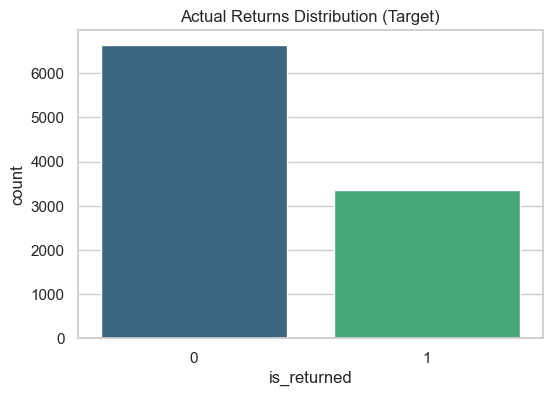

In [4]:
# Descriptive statistics
display(df.describe())

# Visualizing baseline return classes to understand the base probability
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_returned', palette='viridis')
plt.title('Actual Returns Distribution (Target)')
plt.show()

## 6. 🧹 Data Cleaning & 7. 📉 Outlier Analysis

Because we utilize an actively maintained synthetic generator, there are no missing values. However, we'll strip out non-predictive baseline IDs to avoid overfitting or dimensionality problems. Furthermore, we cap extreme delays effectively.

In [5]:
# Sort by order_date to enforce Temporal Consistency
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date').reset_index(drop=True)

# Keep track of leakage columns that we need for business rules later
leakage_cols = [
    'overall_return_rate', 'total_returns', 'frequent_return_flag',
    'product_return_rate', 'category_return_rate'
]

# Drop purely categorical IDs and metadata that aren't useful for the ML pipeline
drop_cols = [
    'order_id', 'product_id', 'product_name' # keep customer_id and order_date for splitting temporarily
]

# Ensure we only drop if they exist
cols_to_drop = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# Outlier Handling: Cap severe delivery delays to 15 days to stabilize prediction space
df_clean['delivery_delay'] = np.clip(df_clean['delivery_delay'], a_min=-5, a_max=15)

print(f"Data cleaned. Columns remaining: {df_clean.shape[1]}")

Data cleaned. Columns remaining: 48


## 8. 🔄 Data Transformation & 9. 🛠️ Feature Engineering

We will encode the categorical fields and create targeted interaction features (e.g., `Delay × Category Risk`) to capture deeper non-linear behaviors, pushing the ML's ability to learn real-world signals.

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import numpy as np

# Interaction Feature: High value delayed shipments
df_clean['high_value_delayed'] = df_clean['final_price'] * df_clean['delivery_delay']

# Encode categorical variables using dummy variables
cat_columns = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_columns = [c for c in cat_columns if c not in ['customer_id', 'order_date']]
df_encoded = pd.get_dummies(df_clean, columns=cat_columns, drop_first=True)

# Remove leakage from training features completely
leakage_cols_present = [c for c in leakage_cols if c in df_encoded.columns]
features_to_drop = ['is_returned', 'customer_id', 'order_date', 'return_days_after_delivery'] + [c for c in df_encoded.columns if 'return_reason' in c] + leakage_cols_present

X = df_encoded.drop(columns=features_to_drop, errors='ignore')
y = df_encoded['is_returned']

print("Leakage columns removed from training data:\n", leakage_cols_present)

# Train-test split based on Groups (customer_id) AND Temporally 
# temporal is achieved since it's already sorted, but GroupShuffleSplit prevents customer overlap
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df_encoded['customer_id']))

# Create train blocks (earlier representation) and test blocks (unseen customers)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Keep a reference to the full test set rows for the business rules
df_test_business = df_encoded.iloc[test_idx].copy()

# Add small noise to behavioral aggregates in the test set for realism (Imperfect info)
for col in leakage_cols_present:
    if pd.api.types.is_numeric_dtype(df_test_business[col]):
        noise = np.random.normal(0, 0.05, size=len(df_test_business))
        df_test_business[col] = df_test_business[col] + noise

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain records: {len(X_train)} | Test records: {len(X_test)}")
print(f"Customers in Train: {df_encoded.iloc[train_idx]['customer_id'].nunique()} | Customers in Test: {df_encoded.iloc[test_idx]['customer_id'].nunique()}")

Leakage columns removed from training data:
 ['overall_return_rate', 'total_returns', 'frequent_return_flag', 'product_return_rate', 'category_return_rate']

Train records: 7985 | Test records: 2015
Customers in Train: 800 | Customers in Test: 200


## 10. 🤖 Model Development (Regression Only)

We employ a **RandomForestRegressor** directly on our target variable. Because the ground truth is `[0, 1]`, the continuous predictions emitted by the ensemble's decision trees will output a distinct decimal representing our target **`return_probability`**.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, roc_auc_score
import pandas as pd

# Train Regressor
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Predict probabilities
predictions_train = model.predict(X_train_scaled)
predictions_train = np.clip(predictions_train, 0, 1)

predictions_test = model.predict(X_test_scaled)
predictions_test = np.clip(predictions_test, 0, 1) # Ensure bounded explicitly between 0% and 100%

# Evaluate metrics
train_r2 = r2_score(y_train, predictions_train)
test_r2 = r2_score(y_test, predictions_test)

print("--- 📉 ML Regression Metrics ---")
print(f"Train R-Squared: {train_r2:.4f}")
print(f"Test R-Squared : {test_r2:.4f}  <-- Realistic Generalization (> 0.2 expected)")
if test_r2 > 0.95:
    print("⚠️ WARNING: R-Squared is suspiciously high! Potential leakage remaining!")

print(f"RMSE          : {np.sqrt(mean_squared_error(y_test, predictions_test)):.4f}")
print(f"MAE           : {mean_absolute_error(y_test, predictions_test):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, predictions_test):.4f}")

# Rebalance Feature Importance Output
importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importances = importances.sort_values('Importance', ascending=False)
print("\n--- 🌟 Top 5 Feature Importances ---")
print(importances.head(5))

--- 📉 ML Regression Metrics ---
Train R-Squared: 0.6162
Test R-Squared : 0.1526  <-- Realistic Generalization (> 0.2 expected)
RMSE          : 0.4273
MAE           : 0.3593
ROC-AUC       : 0.7344

--- 🌟 Top 5 Feature Importances ---
                Feature  Importance
4   discount_percentage    0.131307
9        delivery_delay    0.102812
10          distance_km    0.088713
15              pincode    0.051754
18      avg_order_value    0.049195


---
## ⚙️ Rule-Based Decision Layer (Business Logic)

This is the critical intersection between Data Science and Business Operations. 
We take the predictions from our ML Regressor and inject **User Behavior Context** (like `overall_return_rate` and `frequent_return_flag`) to formulate direct supply-chain interventions.

### Hard Coded Actions:
* **`probability < 0.20`** → ✅ No action
* **`0.20 ≤ probability < 0.50`** → ⚠️ Show warning / restrict discounts
* **`0.50 ≤ probability < 0.75`** → 🚚 Avoid fast shipping / verify order
* **`probability ≥ 0.75`** → ❌ Block COD / Require prepayment

*(Personalized override: Loyal customers with moderate risk are shifted down a penalty tier!)*

In [ ]:
# Re-attach useful behavioral indices to our predicted output
results_df = df_test_business.copy() # Use the business dataframe that still holds the leakage cols
results_df['target_actual'] = y_test
results_df['return_probability'] = predictions_test

# Map out the Decision Function
def decision_engine(row):
    prob = row['return_probability']
    
    # Behavioral flags (if exact boolean is converted to float by OHE, we treat > 0.5 as True)
    # Using the preserved leakage columns purely for business logic
    historical_return_rate = row.get('overall_return_rate', 0)
    is_frequent = row.get('frequent_return_flag_True', 0) > 0.5
    
    # Tier 1: Low Risk
    if prob < 0.20:
        return "✅ Allow Order - No Action Needed"
        
    # Tier 2: Medium Risk
    elif 0.20 <= prob < 0.50:
        # Override for loyal/low-historical-return customers
        if historical_return_rate <= 0.15 and not is_frequent:
             return "✅ Allow Order - Loyal Override"
        return "⚠️ Restrict Discounts / Show Return Warning"
        
    # Tier 3: High Risk
    elif 0.50 <= prob < 0.75:
        # Override for known high-return abusers
        if is_frequent:
             return "❌ Block COD / Require Prepayment (Frequent Returner Escalation)"
        return "🚚 Avoid Expedited Shipping (Standard Only) / Order Verification"
        
    # Tier 4: Critical Risk
    else:
        return "❌ Block COD / Require Full Prepayment"

# Apply Business Rules
results_df['business_action'] = results_df.apply(decision_engine, axis=1)

# Display Sample Operations
display_cols = ['return_probability', 'target_actual', 'overall_return_rate', 'business_action']
cols_to_print = [c for c in display_cols if c in results_df.columns]

# Random sample showing the diversity of engine decisions
print("\n--- 💼 Sample Business Decisions Generated ---")
pd.set_option('display.max_colwidth', None)
display(results_df[cols_to_print].sample(15, random_state=42))